<a href="https://colab.research.google.com/github/yabdulmajeed/Netflix-/blob/main/MAAMOBI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [9]:
#GENERATE SYNTHETIC DATASET
np.random.seed(42)

n = 200  # number of students

ages = np.random.randint(10, 18, n)
heights = np.random.randint(130, 180, n)

# simulate weight with some realistic relationship
weights = (heights * 0.45) + (ages * 1.5) + np.random.normal(0, 3, n)

df = pd.DataFrame({
    "Age": ages,
    "Height": heights,
    "Weight": weights
})

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   Age  Height      Weight
0   16     161   93.237323
1   13     168   96.547417
2   14     178  100.429612
3   16     161   98.592001
4   12     133   79.269713



Summary Statistics:
              Age      Height      Weight
count  200.000000  200.000000  200.000000
mean    13.560000  155.010000   90.279364
std      2.283082   14.405816    7.783464
min     10.000000  130.000000   68.941890
25%     12.000000  143.750000   84.122127
50%     13.000000  157.000000   91.195678
75%     16.000000  166.000000   96.557242
max     17.000000  179.000000  108.639491


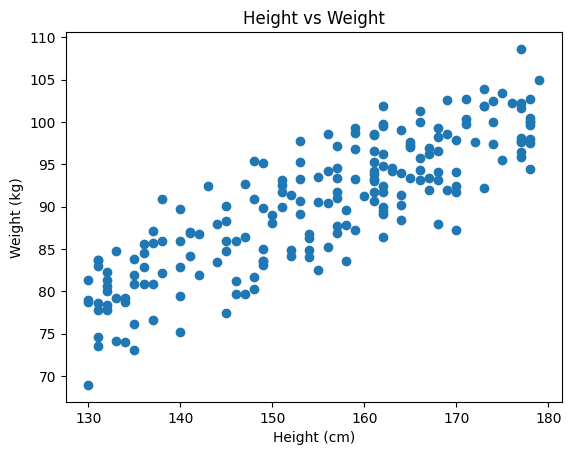

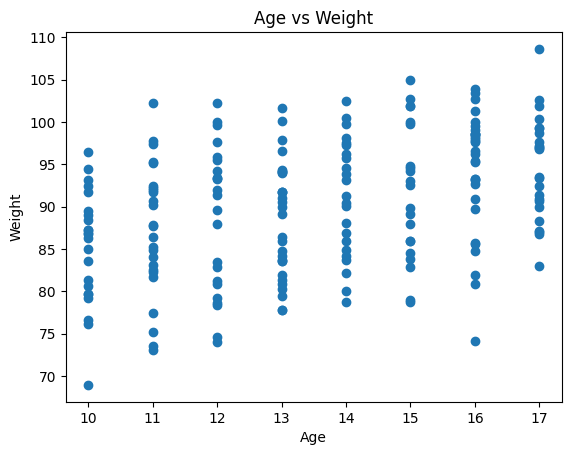

In [10]:
#EXPLORATORY DATA ANALYSIS
print("\nSummary Statistics:")
print(df.describe())

# Scatter plots
plt.scatter(df["Height"], df["Weight"])
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight")
plt.show()

plt.scatter(df["Age"], df["Weight"])
plt.xlabel("Age")
plt.ylabel("Weight")
plt.title("Age vs Weight")
plt.show()

In [12]:
#PREPARE DATA
X = df[["Age", "Height"]]
y = df["Weight"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
#TRAIN MODELS
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "R2": r2
    }


In [17]:
#DISPLAY RESULTS
print("\nModel Performance:")
for model_name, metrics in results.items():
    print(f"\n{model_name}")
    print(f"MAE: {metrics['MAE']:.2f}")
    print(f"MSE: {metrics['MSE']:.2f}")
    print(f"R2 Score: {metrics['R2']:.2f}")


Model Performance:

Linear Regression
MAE: 2.08
MSE: 6.74
R2 Score: 0.85

Decision Tree
MAE: 3.70
MSE: 21.12
R2 Score: 0.54

Random Forest
MAE: 2.56
MSE: 9.37
R2 Score: 0.80


In [19]:
#SELECT BEST MODEL
best_model_name = max(results, key=lambda x: results[x]["R2"])
best_model = models[best_model_name]

print(f"\nBest Model: {best_model_name}")


Best Model: Linear Regression


In [21]:
#SAVE MODEL
joblib.dump(best_model, "student_weight_model.pkl")
print("Model saved as student_weight_model.pkl")

Model saved as student_weight_model.pkl


In [23]:
# TEST WITH NEW DATA
new_data = pd.DataFrame({
    "Age": [14],
    "Height": [160]
})

prediction = best_model.predict(new_data)
print(f"\nPredicted Weight: {prediction[0]:.2f} kg")


Predicted Weight: 93.14 kg
